Project's name: Telecommunications Customer Churn
Project's type: Exploratory Data Analysis (EDA) + Statistics
Dataset: Telco Customer Churn Dataset​(https://www.kaggle.com/datasets/blastchar/telco-customer-churn)
Project Focus: Analyzing customer data and service usage to identify the primary drivers of churn.
Required Analysis:
Descriptive Statistics: Perform EDA on customer tenure, monthly charges, and churn status.
Exponential Distribution: Model the distribution of customer tenure (time until churn/survival analysis).
Two-Sample T-Test: Compare the monthly charges between churned customers and retained customers.
One Proportion Z-Test: Test if the churn rate for senior citizens is significantly higher than the general population.
Chi-Square Test: Test for independence between the type of internet service (DSL, Fiber, None) and customer churn.

In [4]:
import pandas as pd
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [5]:
print(df.columns)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [6]:
df['tenure'].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

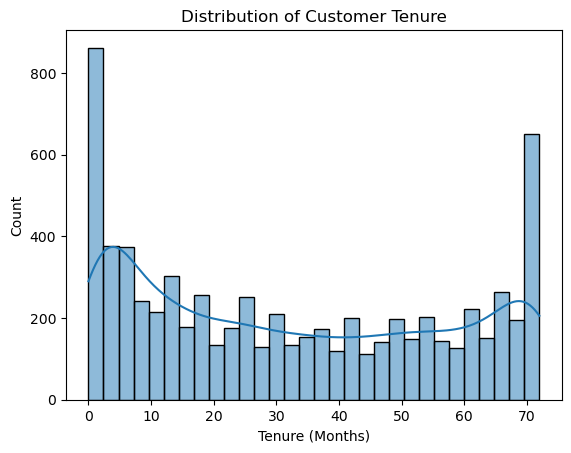

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(df['tenure'], bins=30, kde=True)
plt.title('Distribution of Customer Tenure')
plt.xlabel('Tenure (Months)')
plt.show()

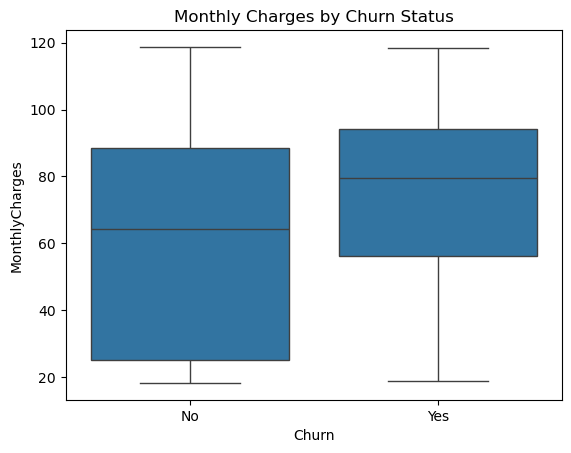

In [11]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges by Churn Status')
plt.show()

In [12]:
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

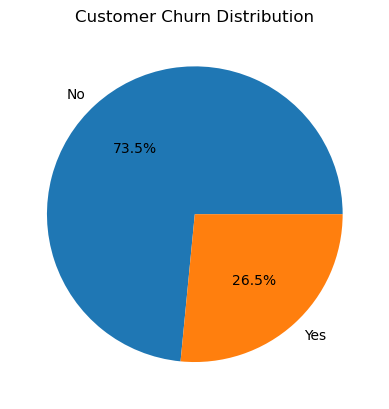

In [26]:
df['Churn'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    ylabel=''
)
plt.title('Customer Churn Distribution')
plt.show()

In [14]:
import numpy as np

mean_tenure = df['tenure'].mean()
lambda_est = 1 / mean_tenure

print("Mean Tenure:", mean_tenure)
print("Lambda:", lambda_est)

Mean Tenure: 32.37114865824223
Lambda: 0.030891705776569148


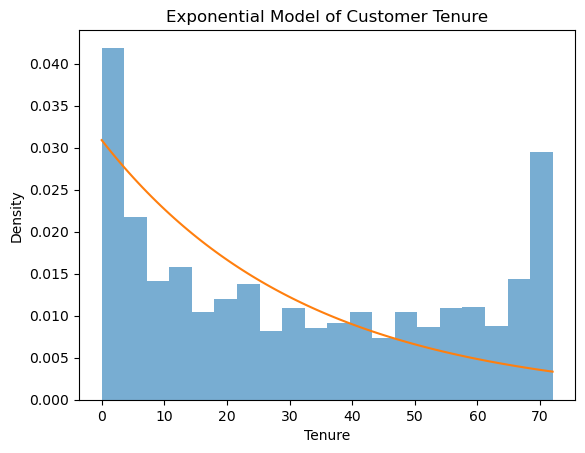

In [15]:
from scipy.stats import expon

x = np.linspace(0, df['tenure'].max(), 100)

pdf = expon.pdf(x, scale=mean_tenure)

plt.hist(df['tenure'],
         bins=20,
         density=True,
         alpha=0.6)

plt.plot(x, pdf)
plt.title('Exponential Model of Customer Tenure')
plt.xlabel('Tenure')
plt.ylabel('Density')
plt.show()

In [16]:
from scipy.stats import ttest_ind

churned = df[df['Churn']=='Yes']['MonthlyCharges']
retained = df[df['Churn']=='No']['MonthlyCharges']

t_stat, p_value = ttest_ind(
    churned,
    retained,
    equal_var=False
)

print("T Statistic:", t_stat)
print("P-value:", p_value)

T Statistic: 18.407526676414673
P-value: 8.59244933154705e-73


In [17]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0")
else:
    print("Fail to Reject H0")

Reject H0


In [18]:
from statsmodels.stats.proportion import proportions_ztest

overall_rate = (df['Churn'] == 'Yes').mean()

senior = df[df['SeniorCitizen'] == 1]

successes = (senior['Churn'] == 'Yes').sum()
n = len(senior)

z_stat, p_value = proportions_ztest(
    count=successes,
    nobs=n,
    value=overall_rate,
    alternative='larger'
)

print("Z Statistic:", z_stat)
print("P-value:", p_value)

Z Statistic: 10.380231031309073
P-value: 1.5251805427658067e-25


In [19]:
pd.crosstab(
    df['InternetService'],
    df['Churn']
)

Churn,No,Yes
InternetService,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113


In [27]:
from scipy.stats import chi2_contingency

table = pd.crosstab(
    df['InternetService'],
    df['Churn']
)

chi2, p_value, dof, expected = chi2_contingency(table)

print("Chi-Square:", chi2)
print("P-value:", p_value)

Chi-Square: 732.309589667794
P-value: 9.571788222840544e-160


In [21]:
if p_value < 0.05:
    print("Reject H0")
else:
    print("Fail to Reject H0")

Reject H0


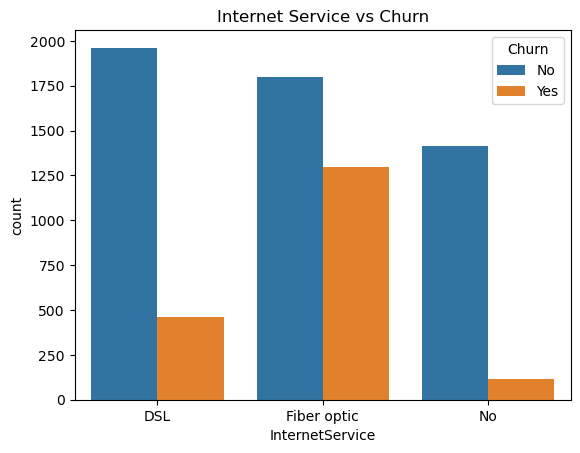

In [22]:
sns.countplot(
    x='InternetService',
    hue='Churn',
    data=df
)

plt.title('Internet Service vs Churn')
plt.show()